# PJM Load Forecasting Evaluation

This notebook displays the real-world electric load forecasting benchmark added to `qrc-engine`. It compares classical baselines and QRC backends on PJM East hourly demand using the same features, split, normalization, and metrics.

## Setup

The notebook reuses the helper functions from `experiments/load_forecasting.py`, so the notebook and script stay aligned.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.load_forecasting import (
    DATA_PATH,
    N_QRC_TEST,
    N_QRC_TRAIN,
    OUT_DIR,
    WASHOUT,
    evaluate,
    fit_classical_models,
    fit_qrc_models,
    load_dataset,
    print_table,
    save_context_plot,
    save_rmse_plot,
    save_time_domain_plot,
    scale_features,
)

plt.style.use('seaborn-v0_8-whitegrid')
DATA_PATH

WindowsPath('C:/Users/moham/OneDrive/Documents/New project/qrc-engine/data/PJME_hourly.csv')

## Load and Prepare Data

In [2]:
X_train, y_train, X_test, y_test = load_dataset()
X_train_scaled, X_test_scaled = scale_features(X_train, X_test)

print(f'Train shape: {X_train_scaled.shape}')
print(f'Test shape:  {X_test_scaled.shape}')
print('Feature count:', X_train_scaled.shape[1])

Loading data...


Train: 140,062 samples | Test: 5,136 samples
Train shape: (140062, 6)
Test shape:  (5136, 6)
Feature count: 6


## Classical Models on the Full 2018 Test Set

In [3]:
classical_full = fit_classical_models(X_train_scaled, y_train, X_test_scaled)
full_results = [
    evaluate('Ridge (full data)', y_test, classical_full['Ridge']),
    evaluate('Random Forest (full data)', y_test, classical_full['Random Forest']),
    evaluate('MLP (full data)', y_test, classical_full['MLP']),
    evaluate('GAM-like (full data)', y_test, classical_full['GAM-like']),
]
print_table(full_results, 'Classical models - full training set')
full_results


  Classical models - full training set
  Model                        |  RMSE (MW) |   MAE (MW) |  MAPE (%) |   NRMSE
  --------------------------------------------------------------------------
  Ridge (full data)            |     2945.4 |     2224.6 |      6.93 |   0.469
  Random Forest (full data)    |     2849.6 |     2119.1 |      6.55 |   0.454
  MLP (full data)              |     2868.8 |     2143.4 |      6.65 |   0.457
  GAM-like (full data)         |     2840.4 |     2129.9 |      6.65 |   0.452


[{'name': 'Ridge (full data)',
  'RMSE (MW)': 2945.357385759287,
  'MAE (MW)': 2224.624522228545,
  'MAPE (%)': 6.9262182642151435,
  'NRMSE': 0.46906365643351006},
 {'name': 'Random Forest (full data)',
  'RMSE (MW)': 2849.594456394948,
  'MAE (MW)': 2119.055440193654,
  'MAPE (%)': 6.546625475139754,
  'NRMSE': 0.4538129062136548},
 {'name': 'MLP (full data)',
  'RMSE (MW)': 2868.7735158765245,
  'MAE (MW)': 2143.4118341502835,
  'MAPE (%)': 6.648277272220275,
  'NRMSE': 0.45686727231906543},
 {'name': 'GAM-like (full data)',
  'RMSE (MW)': 2840.4299305689883,
  'MAE (MW)': 2129.9385098542075,
  'MAPE (%)': 6.654945721785352,
  'NRMSE': 0.4523534072699313}]

## Fair 5,000 / 2,000 Window for Classical vs QRC

In [4]:
X_qrc_train = X_train_scaled[-N_QRC_TRAIN:]
y_qrc_train = y_train[-N_QRC_TRAIN:]
X_qrc_test = X_test_scaled[:N_QRC_TEST]
y_qrc_test = y_test[:N_QRC_TEST]
y_aligned = y_qrc_test[WASHOUT:]

classical_sub = fit_classical_models(X_qrc_train, y_qrc_train, X_qrc_test)
aligned_classical = {name: prediction[WASHOUT:] for name, prediction in classical_sub.items()}

qrc_predictions, qrc_timings = fit_qrc_models(X_qrc_train, y_qrc_train, X_qrc_test)

sub_results = [
    evaluate('Ridge', y_aligned, aligned_classical['Ridge']),
    evaluate('Random Forest', y_aligned, aligned_classical['Random Forest']),
    evaluate('MLP', y_aligned, aligned_classical['MLP']),
    evaluate('GAM-like', y_aligned, aligned_classical['GAM-like']),
    evaluate('QRC Qiskit (ridge)', y_aligned, qrc_predictions['QRC Qiskit (ridge)']),
    evaluate('QRC Qiskit (RF readout)', y_aligned, qrc_predictions['QRC Qiskit (RF readout)']),
    evaluate('QRC Dynamiqs', y_aligned, qrc_predictions['QRC Dynamiqs']),
    evaluate('QRC Perceval Fock+FB', y_aligned, qrc_predictions['QRC Perceval Fock+FB']),
]

print_table(sub_results, f'Fair comparison - same {N_QRC_TRAIN:,}-sample window')
qrc_timings


Training QRC models...
  Qiskit (ridge)... 

done (24s)
  Qiskit (RF readout)... 

done (28s)
  Dynamiqs... 

done (5s)
  Perceval Fock+Feedback... 

done (81s)

  Fair comparison - same 5,000-sample window
  Model                        |  RMSE (MW) |   MAE (MW) |  MAPE (%) |   NRMSE
  --------------------------------------------------------------------------
  Ridge                        |     2662.3 |     2131.0 |      6.71 |   0.573
  Random Forest                |     3676.8 |     2951.3 |      9.29 |   0.791
  MLP                          |     2614.3 |     2080.3 |      6.53 |   0.563
  GAM-like                     |     2703.1 |     2162.3 |      6.77 |   0.582
  QRC Qiskit (ridge)           |     6746.9 |     5790.4 |     18.84 |   1.452
  QRC Qiskit (RF readout)      |     9622.1 |     7952.9 |     25.68 |   2.071
  QRC Dynamiqs                 |     5606.8 |     4268.2 |     12.67 |   1.207
  QRC Perceval Fock+FB         |     6793.0 |     5630.9 |     16.34 |   1.462


{'QRC Qiskit (ridge)': 24.341967799933627,
 'QRC Qiskit (RF readout)': 27.802009299979545,
 'QRC Dynamiqs': 5.105328899924643,
 'QRC Perceval Fock+FB': 81.43159059993923}

## Inline Comparison Plots

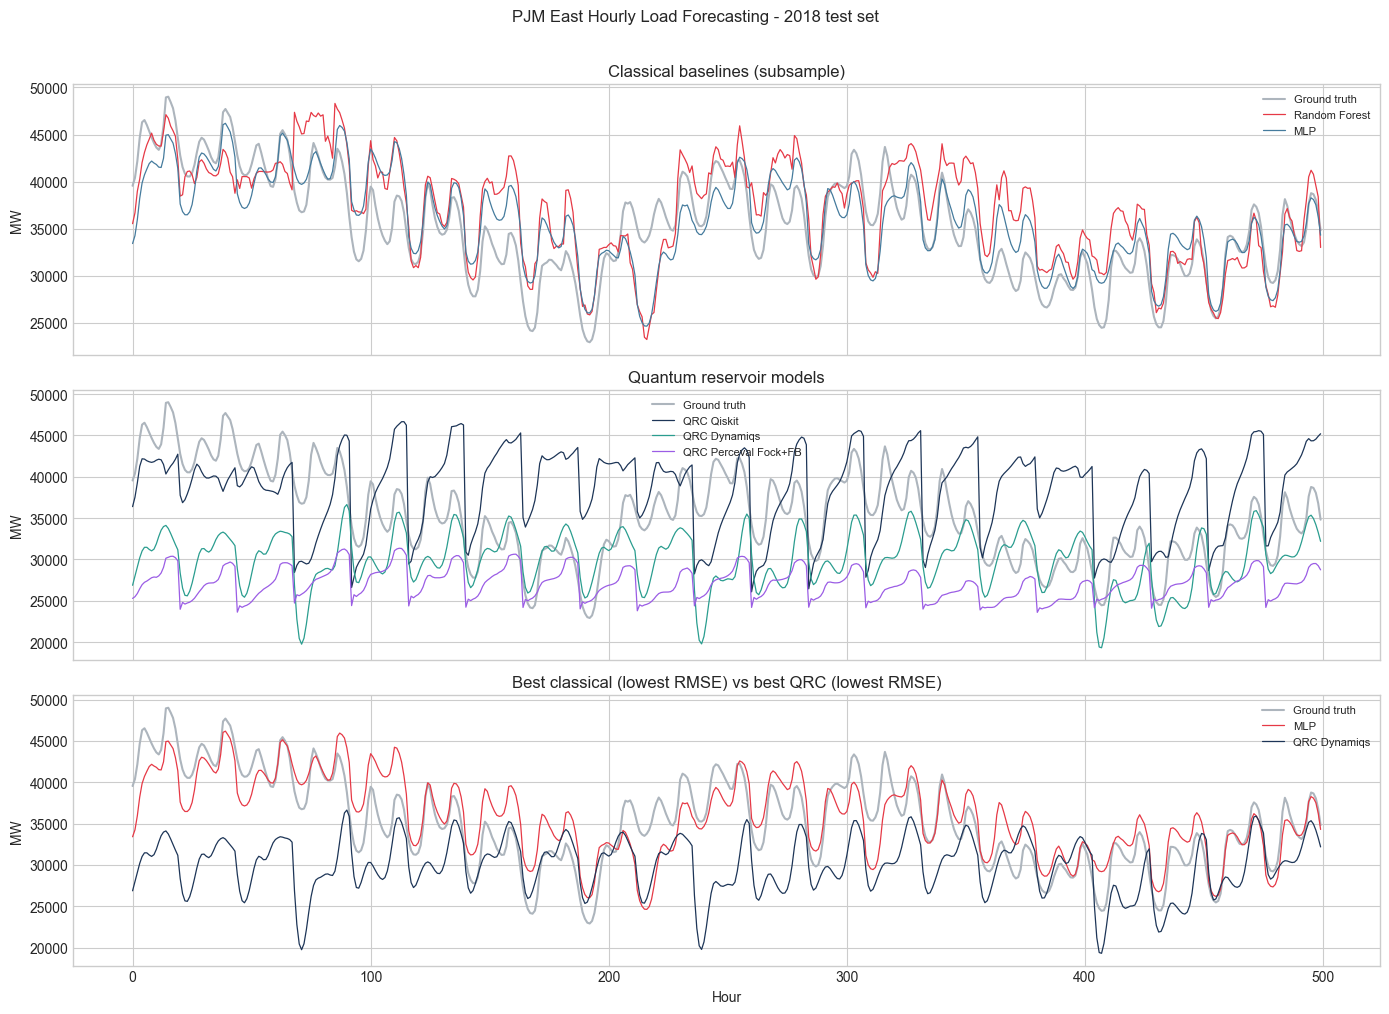

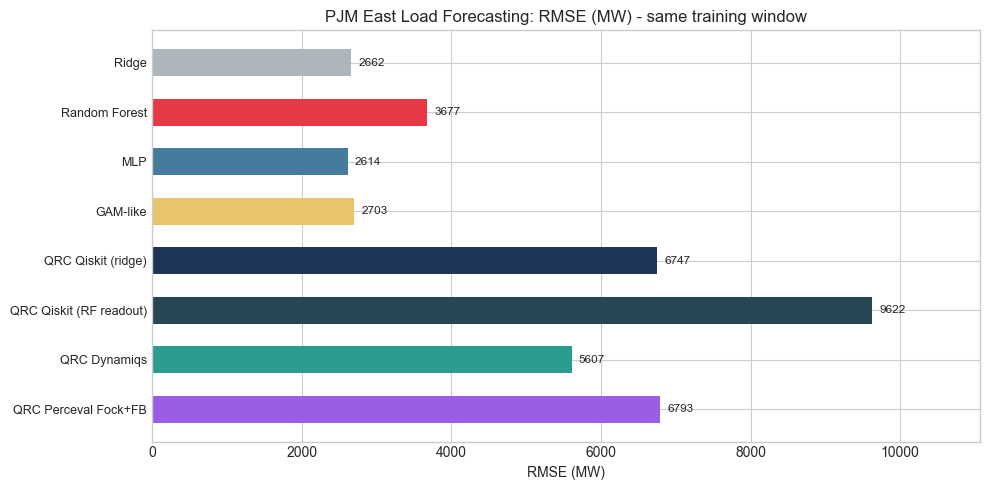

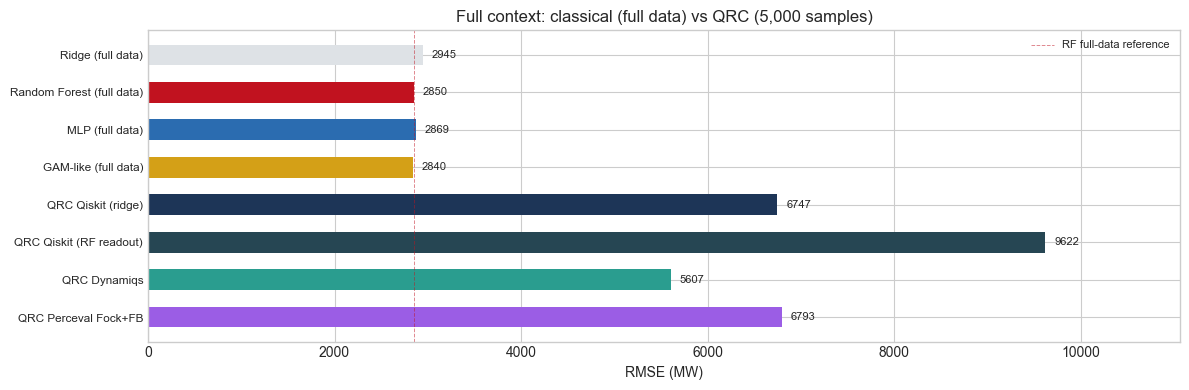

In [5]:
save_time_domain_plot(y_aligned, aligned_classical, qrc_predictions, sub_results)
save_rmse_plot(sub_results)
save_context_plot(full_results, sub_results)

## Notes

- Classical models currently win clearly on this real-world benchmark.
- Among the tested QRC variants here, Dynamiqs performed best on the fair subsample.
- The notebook stays aligned with the script by importing its helpers directly.